In [5]:
# =============================================================================
# 1: Setup & Datenextraktion
# =============================================================================
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Design-Einstellungen
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Verbindung zur DB
conn = sqlite3.connect("../data/fitness_mock.db")

# Alle Trainings laden
df_trainings = pd.read_sql_query("SELECT * FROM trainings", conn)
df_trainings['datum'] = pd.to_datetime(df_trainings['datum'])

print(f"✓ Daten geladen: {len(df_trainings)} Trainingseinheiten")
df_trainings.head()



✓ Daten geladen: 100 Trainingseinheiten


,id,nutzer_id,typ,datum,uhrzeit,dauer_min,wertung
0,1,1,Dauerlauf,2026-01-01,18:00,61,59.52
1,2,1,Sprint,2026-01-02,18:00,41,76.34
2,3,1,Krafttraining,2026-01-03,18:00,60,289.05
3,4,1,Sprint,2026-01-04,18:00,24,38.62
4,5,1,Dauerlauf,2026-01-05,18:00,59,64.76


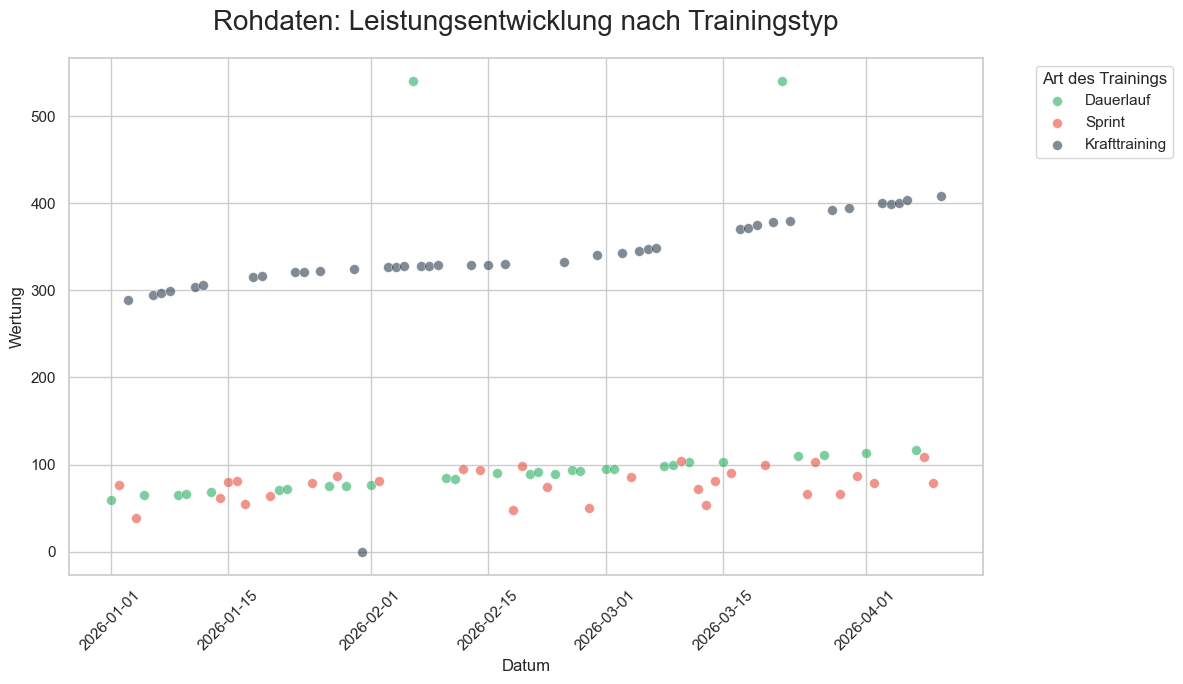

In [24]:
# =============================================================================
# 2: Explorative Analyse (vor Datenbereinigung)
# =============================================================================
# --- Scatterplot: Rohdaten nach Typ ---
plt.figure(figsize=(12, 7))
colors = {"Krafttraining": "#2c3e50", "Dauerlauf": "#27ae60", "Sprint": "#e74c3c"}

for t in df_trainings['typ'].unique():
    subset = df_trainings[df_trainings['typ'] == t]
    plt.scatter(subset['datum'], subset['wertung'],
                label=t, color=colors.get(t, "blue"),
                alpha=0.6, s=50, edgecolors='w', linewidth=0.5)

plt.title('Rohdaten: Leistungsentwicklung nach Trainingstyp', fontsize=20, pad=20)
plt.xlabel('Datum', fontsize=12)
plt.ylabel('Wertung', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Art des Trainings", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


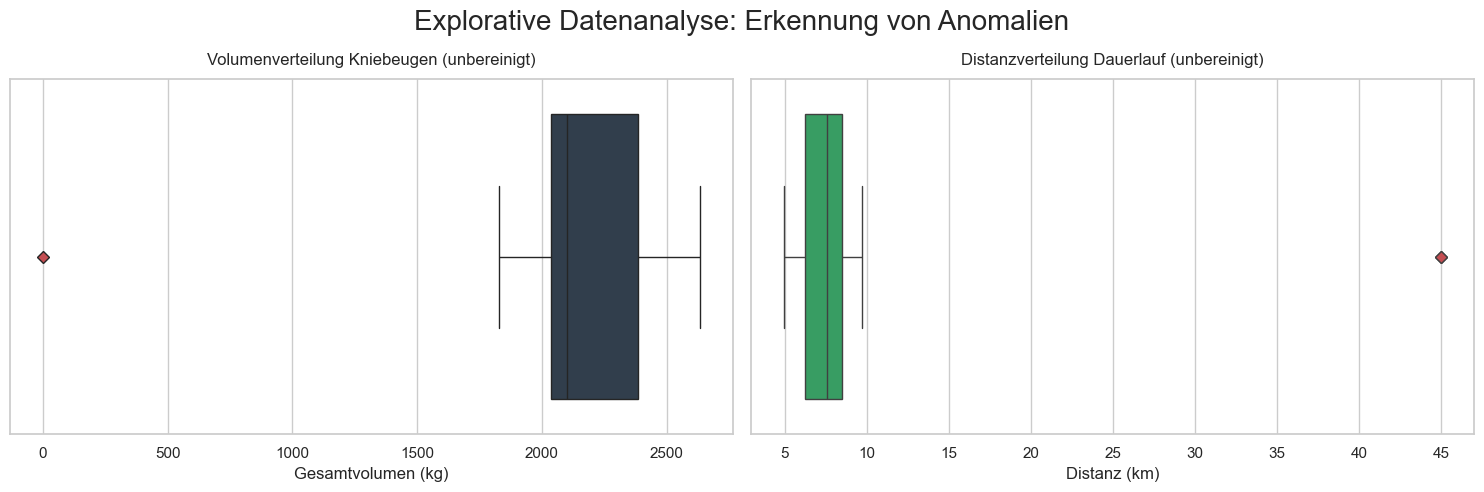

⚠ Visuell erkannte Ausreißer:
  - Kniebeugen: 1 Null-Werte
  - Dauerlauf: 2 Distanz-Ausreißer


In [26]:
# --- Boxplots: Untersuchung auf Ausreißer ---
query_kraft = """
SELECT t.datum, k.name, (k.saetze * k.wdh * k.gewicht) as volumen
FROM trainings t
JOIN krafttraining_uebungen k ON t.id = k.training_id
WHERE t.typ = 'Krafttraining'
"""
df_kraft = pd.read_sql_query(query_kraft, conn)
df_squats_raw = df_kraft[df_kraft["name"] == "Kniebeugen"].sort_values("datum").copy()

query_lauf = """
SELECT t.id, t.datum, t.dauer_min, t.wertung, l.distanz_km
FROM trainings t
LEFT JOIN dauerlauf_details l ON t.id = l.training_id
"""
df_lauf_all = pd.read_sql_query(query_lauf, conn)
df_lauf_only = df_lauf_all[df_lauf_all["distanz_km"].notna()]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df_squats_raw, x="volumen", ax=axes[0],
            color="#2c3e50", flierprops=dict(markerfacecolor="r", marker="D"))
axes[0].set_title("Volumenverteilung Kniebeugen (unbereinigt)", fontsize=12, pad=10)
axes[0].set_xlabel("Gesamtvolumen (kg)")

sns.boxplot(data=df_lauf_only, x="distanz_km", ax=axes[1],
            color="#27ae60", flierprops=dict(markerfacecolor="r", marker="D"))
axes[1].set_title("Distanzverteilung Dauerlauf (unbereinigt)", fontsize=12, pad=10)
axes[1].set_xlabel("Distanz (km)")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.suptitle("Explorative Datenanalyse: Erkennung von Anomalien",
             fontsize=20, y=0.98)
plt.show()

print(f"⚠ Visuell erkannte Ausreißer:")
print(f"  - Kniebeugen: {len(df_squats_raw[df_squats_raw['volumen'] == 0])} Null-Werte")
print(f"  - Dauerlauf: {len(df_lauf_only[df_lauf_only['distanz_km'] > 40])} Distanz-Ausreißer")

In [28]:
# =============================================================================
# 3: Statistische Datenbereinigung
# =============================================================================
print("=== DATENBEREINIGUNG STARTET ===\n")

# --- 3.1: Krafttraining bereinigen (über doppelte Standardabweichung) ---

df_squats = df_squats_raw.copy()

mean_vol = df_squats["volumen"].mean()
std_vol = df_squats["volumen"].std()

print(f"Kniebeugen-Statistik:")
print(f"  μ = {mean_vol:.2f} kg, σ = {std_vol:.2f} kg")
print(f"  Akzeptanzbereich: [{mean_vol - 2*std_vol:.2f}, {mean_vol + 2*std_vol:.2f}] kg")

df_squats_cleaned = df_squats[
    (df_squats["volumen"] >= mean_vol - 2 * std_vol) &
    (df_squats["volumen"] <= mean_vol + 2 * std_vol)
].copy()

removed_kraft = len(df_squats) - len(df_squats_cleaned)
print(f"  → {removed_kraft} Ausreißer entfernt ({removed_kraft/len(df_squats)*100:.1f}%)\n")

df_squats_cleaned["volumen_trend"] = (
    df_squats_cleaned["volumen"].rolling(window=5, min_periods=1).mean()
)

# --- 3.2: Trainings-Gesamttabelle bereinigen ---
print(f"Trainings-Gesamttabelle:")
print(f"  Vor Bereinigung: {len(df_trainings)} Einträge")

# Heuristischer Filter über den Lauf-DataFrame
df_trainings_cleaned = df_lauf_all[
    (df_lauf_all["wertung"] > 0) &
    (df_lauf_all["dauer_min"] < 120) &
    ((df_lauf_all["distanz_km"].isna()) | (df_lauf_all["distanz_km"] < 40))
].copy()

removed_trainings = len(df_trainings) - len(df_trainings_cleaned)
print(f"  → {removed_trainings} Einträge entfernt ({removed_trainings/len(df_trainings)*100:.1f}%)")
print(f"  Nach Bereinigung: {len(df_trainings_cleaned)} Einträge\n")

print("=== BEREINIGUNG ABGESCHLOSSEN ===\n")

=== DATENBEREINIGUNG STARTET ===

Kniebeugen-Statistik:
  μ = 2136.22 kg, σ = 415.29 kg
  Akzeptanzbereich: [1305.65, 2966.80] kg
  → 1 Ausreißer entfernt (2.5%)

Trainings-Gesamttabelle:
  Vor Bereinigung: 100 Einträge
  → 3 Einträge entfernt (3.0%)
  Nach Bereinigung: 97 Einträge

=== BEREINIGUNG ABGESCHLOSSEN ===



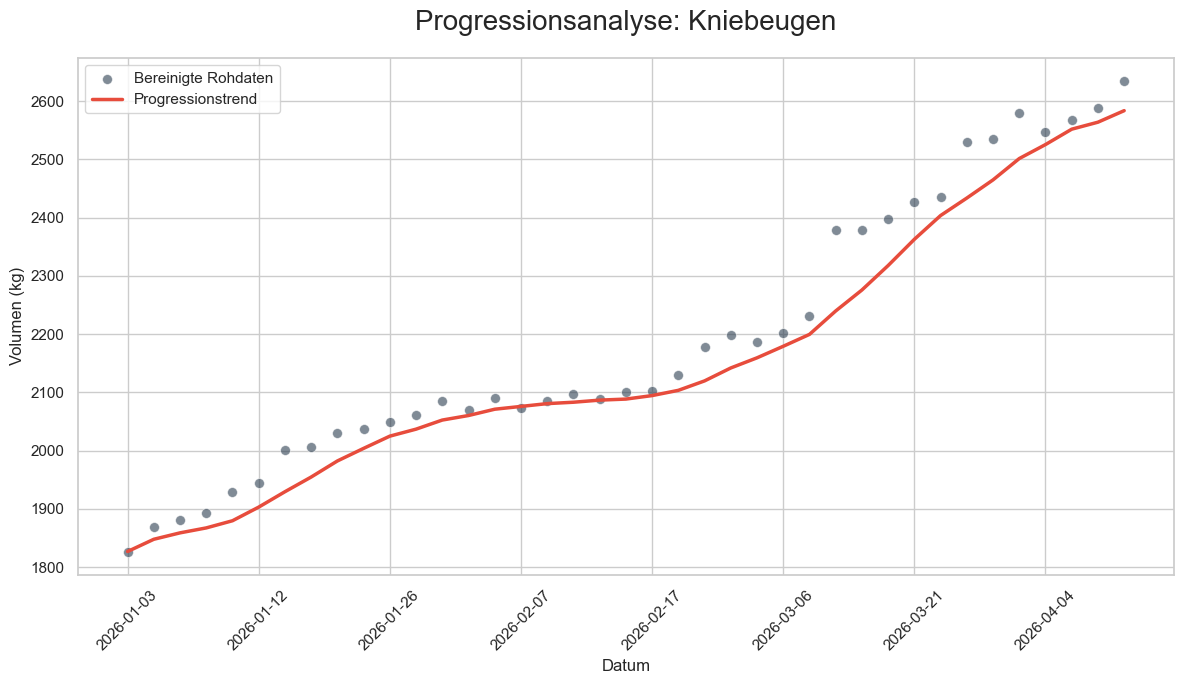

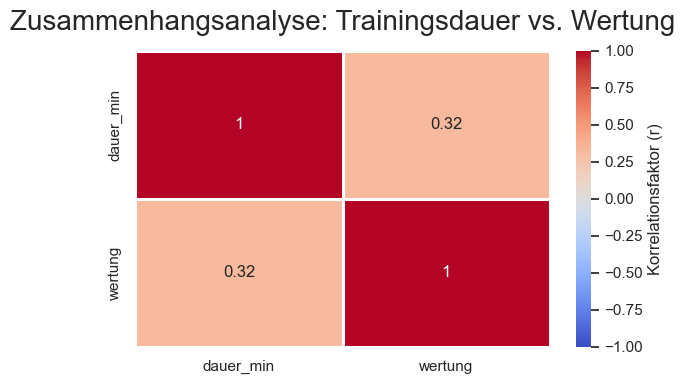


✓ Alle Analysen abgeschlossen und DB-Verbindung geschlossen.


In [29]:
# =============================================================================
# 4: Visualisierungen auf bereinigten Daten
# =============================================================================

# --- 4.1: Progressionsanalyse Kniebeugen ---
plt.figure(figsize=(12, 7))

sns.scatterplot(data=df_squats_cleaned, x="datum", y="volumen",
                color="#2c3e50", alpha=0.6, s=50, label="Bereinigte Rohdaten")

sns.lineplot(data=df_squats_cleaned, x="datum", y="volumen_trend",
             color="#e74c3c", linewidth=2.5, label="Progressionstrend")

plt.title("Progressionsanalyse: Kniebeugen", fontsize=20, pad=20)
plt.xlabel("Datum", fontsize=12)
plt.ylabel("Volumen (kg)", fontsize=12)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=10))
plt.xticks(rotation=45)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# --- 4.2: Korrelationsanalyse ---
all_features = df_trainings_cleaned[["dauer_min", "wertung"]]
corr_matrix = all_features.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=1, linecolor="white",
            cbar_kws={"label": "Korrelationsfaktor (r)"})

plt.title("Zusammenhangsanalyse: Trainingsdauer vs. Wertung",
          fontsize=20, pad=15)
plt.tight_layout()
plt.show()

# Verbindung schließen, um Ressourcen freizugeben
conn.close()
print(f"\n✓ Alle Analysen abgeschlossen und DB-Verbindung geschlossen.")